## Step 1: Initializing Packages and Parameters
In this step, we install and import the machine learning libraries needed to analyze the housing dataset. We also set up our file paths and seed values upfront for clean, reusable code.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

pd.set_option('display.max_columns', 100)

train_file = 'train.csv'
test_file = 'test.csv'
target_col = 'SalePrice'
id_col = 'Id'
seed_value = 42


In [ ]:
housing_train = pd.read_csv(train_file)
housing_test = pd.read_csv(test_file)

print(f"Training set dimensions: {housing_train.shape}")
print(f"Testing set dimensions: {housing_test.shape}")
housing_train.head()


Training set dimensions: (1460, 81)
Testing set dimensions: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


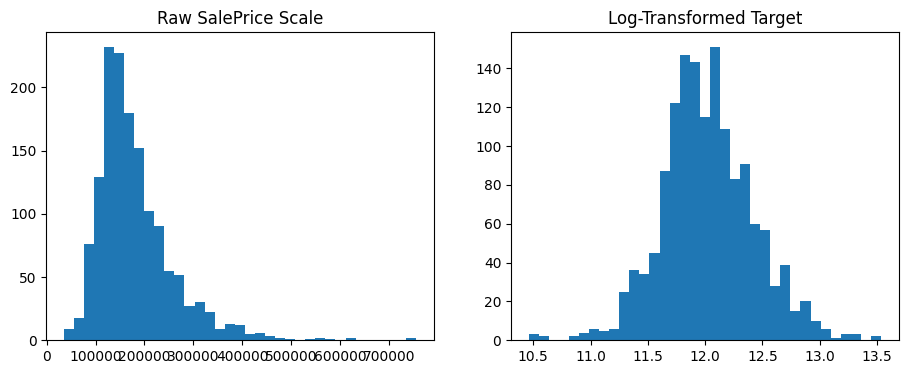

In [4]:
fig, charts = plt.subplots(1, 2, figsize=(11, 4))
charts[0].hist(housing_train['SalePrice'], bins=35)
charts[0].set_title('Raw SalePrice Scale')

charts[1].hist(np.log1p(housing_train['SalePrice']), bins=35)
charts[1].set_title('Log-Transformed Target')
plt.show()


In [5]:
total_train_rows = housing_train.shape[0]
target_log_vector = np.log1p(housing_train['SalePrice'])
full_dataset = pd.concat([housing_train.drop('SalePrice', axis=1), housing_test], axis=0, ignore_index=True)

empty_is_none_features = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for target_column_name in empty_is_none_features:
    full_dataset[target_column_name] = full_dataset[target_column_name].fillna('None')

empty_is_zero_features = [
    'GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath'
]
for target_column_name in empty_is_zero_features:
    full_dataset[target_column_name] = full_dataset[target_column_name].fillna(0)

full_dataset['LotFrontage'] = full_dataset.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

missing_mode_features = [
    'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
    'Electrical', 'KitchenQual', 'Functional', 'SaleType'
]
for target_column_name in missing_mode_features:
    full_dataset[target_column_name] = full_dataset[target_column_name].fillna(full_dataset[target_column_name].mode()[0])

print("Total Unassigned Cells Remaining:", full_dataset.isnull().sum().sum())


Total Unassigned Cells Remaining: 0


In [ ]:

full_dataset['MSSubClass'] = full_dataset['MSSubClass'].astype(str)

rating_scale_mapping = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ordered_rating_columns = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]

for target_column_name in ordered_rating_columns:
    full_dataset[target_column_name] = full_dataset[target_column_name].map(rating_scale_mapping)

full_dataset['BsmtExposure'] = full_dataset['BsmtExposure'].map({'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4})
full_dataset['BsmtFinType1'] = full_dataset['BsmtFinType1'].map({'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
full_dataset['BsmtFinType2'] = full_dataset['BsmtFinType2'].map({'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
full_dataset['GarageFinish'] = full_dataset['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})


In [ ]:
full_dataset = pd.get_dummies(full_dataset, drop_first=True)

matrix_X = full_dataset.iloc[:len(housing_train), :].drop('Id', axis=1)
matrix_X_test = full_dataset.iloc[len(housing_train):, :].drop('Id', axis=1)

print("Final Feature Array Shape:", matrix_X.shape)
print("Final Evaluation Array Shape:", matrix_X_test.shape)


Final Feature Array Shape: (1460, 228)
Final Evaluation Array Shape: (1459, 228)


In [9]:
X_train, X_val, y_train, y_val = train_test_split(matrix_X, target_log_vector, test_size=0.2, random_state=seed_value)

gradient_boosting_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=seed_value
)
gradient_boosting_model.fit(X_train, y_train)

validation_estimations = gradient_boosting_model.predict(X_val)
validation_rmse_score = np.sqrt(mean_squared_error(y_val, validation_estimations))
print(f"Validation Root Mean Squared Error (Log Space): {validation_rmse_score:.4f}")


Validation Root Mean Squared Error (Log Space): 0.1319


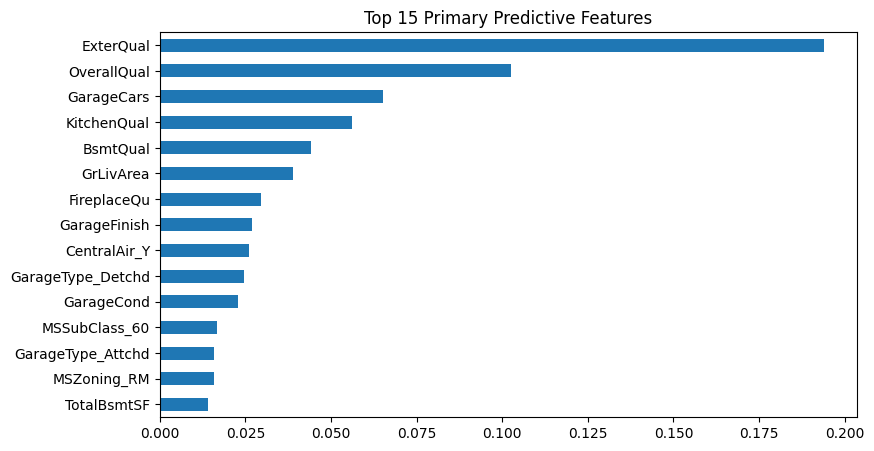

In [10]:
structural_weights = pd.Series(gradient_boosting_model.feature_importances_, index=matrix_X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
structural_weights.sort_values().plot(kind='barh')
plt.title('Top 15 Primary Predictive Features')
plt.show()


In [11]:
final_production_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=seed_value
)
final_production_model.fit(matrix_X, target_log_vector)

predicted_prices_log = final_production_model.predict(matrix_X_test)
predicted_prices_dollars = np.expm1(predicted_prices_log)

final_submission_frame = pd.DataFrame({'Id': housing_test['Id'], 'SalePrice': predicted_prices_dollars})
final_submission_frame.to_csv('submission.csv', index=False)
final_submission_frame.head()


,Id,SalePrice
0,1461,120274.046875
1,1462,159467.218750
2,1463,188644.156250
3,1464,191580.531250
4,1465,186334.562500
